# 03 — Treino QLoRA Florence-2

## O que esta fase faz

Fine-tuning **LoRA** sobre Florence-2-large (4-bit) para gerar JSON estruturado a partir do crop.

## Por que QLoRA

- ~3,5M parâmetros treináveis (0,8% do modelo)
- Cabe em GPU consumer (16 GB VRAM)
- Baseline Florence-2 **não** produz JSON válido nesta tarefa

## Hiperparâmetros principais (`configs/qlora.yaml`)

| Parâmetro | Valor | Motivo |
|-----------|-------|--------|
| lr | 1e-4 | Dataset pequeno |
| épocas | 8 | Early stopping |
| eval_steps | 50 | Melhor checkpoint por eval_loss |
| load_best_model_at_end | true | Não salva última época overfitada |

In [1]:
from __future__ import annotations
import json, os, sys
from pathlib import Path

ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "src" / "hidrometro").exists()), None)
if ROOT is None:
    raise RuntimeError("Execute a partir de vit-tcc-qlora-hidrometro/ ou notebooks/")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from hidrometro.config import load_yaml, resolve_path

qlora_cfg = load_yaml("qlora.yaml")
adapter_dir = resolve_path(qlora_cfg["output_dir"])
display(pd.DataFrame([
    {"secao": s, "parametro": k, "valor": v}
    for s, vals in qlora_cfg.items() if isinstance(vals, dict)
    for k, v in vals.items()
]))

,secao,parametro,valor
0,model,name,microsoft/Florence-2-large
1,model,trust_remote_code,True
2,model,load_in_4bit,True
3,model,bnb_4bit_quant_type,nf4
4,model,bnb_4bit_compute_dtype,bfloat16
5,model,torch_dtype,bfloat16
6,lora,r,16
7,lora,lora_alpha,32
8,lora,target_modules,"[q_proj, v_proj, k_proj, o_proj]"
9,lora,lora_dropout,0.05


## Treino opcional

Por padrão **`RUN_TRAINING = False`** — reutiliza `artifacts/lora_adapter/`.

In [2]:
RUN_TRAINING = True
NUM_EPOCHS = None  # None = configs/qlora.yaml

if RUN_TRAINING:
    from hidrometro.training.train_qlora import train_qlora

    sft = resolve_path(load_yaml("paths.yaml")["output"]["sft"])
    out = train_qlora(sft / "train.jsonl", sft / "val.jsonl", num_epochs=NUM_EPOCHS)
    print(f"Adaptador salvo em: {out}")
else:
    print(f"Adaptador existente: {adapter_dir}")

c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
W0703 23:15:48.251000 45648 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences betwee

Step,Training Loss,Validation Loss
50,1.181800,0.909869
100,0.270000,0.334913
150,0.173000,0.239094
200,0.134600,0.241581
250,0.162400,0.230197
300,0.131600,0.212049
350,0.126700,0.211750
400,0.099800,0.207267
450,0.114000,0.206847
500,0.132000,0.206884


c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Ref

Melhor checkpoint (eval_loss): C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\artifacts\lora_adapter\checkpoint-450
Melhor metric: 0.2068471759557724
Train loss final: 0.4720
Adaptador salvo em: C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\artifacts\lora_adapter


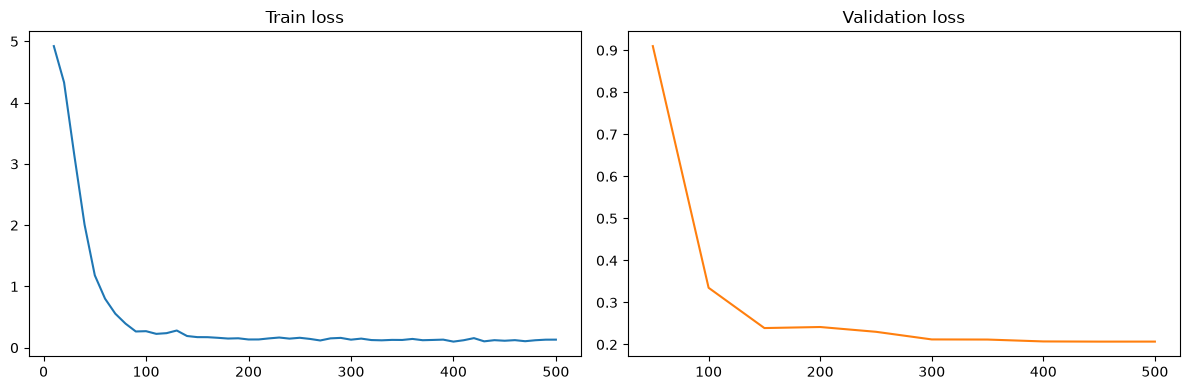

Melhor checkpoint: C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\artifacts\lora_adapter\checkpoint-450
Melhor eval_loss: 0.2068471759557724


In [3]:
def latest_state(path: Path):
    cks = sorted(path.glob("checkpoint-*/trainer_state.json"))
    if cks:
        return cks[-1]
    p = path / "trainer_state.json"
    return p if p.exists() else None

state_path = latest_state(adapter_dir)
if state_path and state_path.exists():
    state = json.loads(state_path.read_text(encoding="utf-8"))
    history = state["log_history"]
    train_logs = [x for x in history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in history if "eval_loss" in x]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot([x["step"] for x in train_logs], [x["loss"] for x in train_logs])
    ax[0].set_title("Train loss")
    ax[1].plot([x["step"] for x in eval_logs], [x["eval_loss"] for x in eval_logs], color="C1")
    ax[1].set_title("Validation loss")
    plt.tight_layout()
    plt.show()
    print(f"Melhor checkpoint: {state.get('best_model_checkpoint')}")
    print(f"Melhor eval_loss: {state.get('best_metric')}")
else:
    print("trainer_state.json não encontrado — treino ainda não executado ou path diferente.")

**Próximo notebook:** `04_resultados_comparativos.ipynb` — baseline vs QLoRA em percentuais.